In [1]:
# Standard libraries
# import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch core
import torch
import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader

# Custom project modules
from utils.train_test_loop import train_and_evaluate
# from utils.losses import FwdLoss, EMLoss, FwdBwdLoss, MarginalChainLoss
from utils.losses1 import MarginalChainProperLoss, ForwardProperLoss, scoring_matrix
from utils.losses1 import PiCOLoss, IRLoss, UpperBoundWeakProperLoss, ForwardBackwardProperLoss
# from utils.dataset_visualization import visualize_dataset
from src.weakener import Weakener
from src.model import MLP
from src.dataset import Data_handling

# Set random seeds for reproducibility
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [2]:
# dataset_name = 'Cifar10'
dataset_name = 'mnist'
Data = Data_handling(
    dataset=dataset_name,
    train_size=0.8,
    test_size=0.2,
    batch_size=64,
    shuffling=False,
    splitting_seed=42,
)

In [3]:
Data.train_dataset.data # This is Train_X
Data.train_dataset.targets # This is Train_y

print(f"Number of classes: {Data.num_classes}")
print(f"Array of targets: \n {Data.test_dataset.targets}")
df = pd.DataFrame(
    Data.train_dataset.data.numpy(),
    # columns=[f'feature_{i}' 
    columns=[f'x_{i}' 
             for i in range(Data.train_dataset.data.shape[1])])

# Add target column
df['target'] = [i for i in Data.train_dataset.targets.numpy()]

# Print 3 rows
print(df.head(3))

Number of classes: 10
Array of targets: 
 tensor([[0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
   x_0  x_1  x_2  x_3  x_4  x_5  x_6  x_7  x_8  x_9  ...  x_775  x_776  x_777  \
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0    0.0   
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0    0.0   
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0    0.0    0.0   

   x_778  x_779  x_780  x_781  x_782  x_783  \
0    0.0    0.0    0.0    0.0    0.0    0.0   
1    0.0    0.0    0.0    0.0    0.0    0.0   
2    0.0    0.0    0.0    0.0    0.0    0.0   

                                              target  
0  [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...  
1  [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
2  [0.0, 0.0, 0.0, 0.0, 1

In [4]:
# Generate transition matrix M
corr_p = 0.2
weakener = Weakener(true_classes=Data.num_classes)
weakener.generate_M(model_class='pll', corr_p=corr_p) # For noisy labels
# weakener.generate_M(model_class='unif_noise', corr_p=0.5) # For noisy labels
print(f"Generated M matrix:\n"
      f"{np.array2string(weakener.M, precision=4, suppress_small=True)}")

# Generate weak labels z
true_onehot = Data.train_dataset.targets  # shape: (n_samples, n_classes)
z = weakener.generate_weak(
    true_onehot, compute_w=True, compute_Y=True, compute_Y_opt=True,
    compute_Y_conv=True, compute_Y_opt_conv=True)
print(f"Generated weak labels z:\n{z}")

# Compute virtual labels
print("Computing virtual labels...")
# Since z[i] is an integer, row i must contain the z[i]-th row of weakener.Z
virtual_labels = weakener.Z[z]

# Add weak and virtual labels to the dataset
Data.include_weak(z)
Data.include_virtual(virtual_labels, initial_weight=1/Data.num_classes)

# Get dataloaders with weak labels and indices
train_loader, test_loader = Data.get_dataloader(
    weak_labels='all', get_index=True)

Generated M matrix:
[[0.     0.     0.     ... 0.     0.     0.1342]
 [0.     0.     0.     ... 0.     0.1342 0.    ]
 [0.     0.     0.     ... 0.     0.0336 0.0336]
 ...
 [0.     0.     0.     ... 0.     0.     0.    ]
 [0.     0.     0.     ... 0.     0.     0.    ]
 [0.     0.     0.     ... 0.     0.     0.    ]]
Generated weak labels z:
tensor([144, 648, 176,  ...,  17,  23,  18], dtype=torch.int32)
Computing virtual labels...


In [5]:
batch = next(iter(train_loader))
xb, wb, vb, cb, yb, ib = batch
print(f"Inputs batch: shape {xb.shape}")
print(f"Weak (partial) labels: shape {wb.shape}, first row: {wb[0]}")
print(f"Virtual labels: shape {vb.shape}, first row: {vb[0]}")
print(f"Weights: shape {cb.shape}, first row: {cb[0]}")
print(f"True one-hot labels shape: {yb.shape}, first row: {yb[0]}")
print(f"Indices batch: shape {ib.shape}, first row: {ib[0]}")

Inputs batch: shape torch.Size([64, 784])
Weak (partial) labels: shape torch.Size([64]), first row: 144
Virtual labels: shape torch.Size([64, 10]), first row: tensor([0, 0, 1, 0, 0, 1, 0, 0, 0, 1])
Weights: shape torch.Size([64, 10]), first row: tensor([0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000])
True one-hot labels shape: torch.Size([64, 10]), first row: tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])
Indices batch: shape torch.Size([64]), first row: 0


In [6]:
weak_df = pd.DataFrame(Data.train_dataset.data.numpy(), columns=[f'x_{i}' for i in range(Data.train_dataset.data.shape[1])])
df['target'] = [i for i in weakener.w.numpy()]

In [7]:
# ##########################
# Define model and optimizer
def get_model(Data, opt_alg='adam', lr=1e-6, momentum=0.9):
    """ Define model and optimizer
    Parameters
        Data: dataset object with num_classes and num_features attributes
    Returns
        model: the neural network model
        optimizer: the optimizer
    """

    model = MLP(
        input_size=Data.num_features,
        hidden_sizes=[],
        output_size=Data.num_classes,
        dropout_p=0,
        bn=False,
        activation='relu')

    if opt_alg == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif opt_alg == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    else:
        raise ValueError(f"Unsupported optimizer: {opt_alg}") 

    return model, optimizer

# ########################
# Visualization of results
def plot_results(results_df):
    """ Plot training results
    Parameters
        results_df: DataFrame with training results
    """

    # Set up a wide figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

    # Loss curves
    ax1.plot(results_df['epoch'], results_df['train_loss'], label='Train Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss Curve')
    ax1.legend()
    ax1.grid(True)

    # Accuracy curves
    ax2.plot(results_df['epoch'], results_df['train_acc'], label='Train Accuracy')
    ax2.plot(results_df['epoch'], results_df['test_acc'], label='Test Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy Curves')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()

In [8]:
def run_simulation(Data, loss, num_epochs=10, optimizer_name='adam', 
                   loss_code=None, pseudolabel_model=None, lr=1e-6, phi=0.8):
    """ Run a training simulation with the specified parameters.

    Parameters
    ----------
    Data : dataset object
        The dataset object containing training and test data.
    loss : loss function object
        The loss function to use for training.
    num_epochs : int, optional
        The number of training epochs (default is 10).
    optimizer_name : str, optional
        The name of the optimizer to use (default is 'adam').
    loss_code : str, optional
        A code representing the loss function (for metadata) (default is None).
    pseudolabel_model : str, optional
        A string indicating the pseudolabel model used (for metadata)
        (default is None).
    lr : float, optional
        The learning rate for the optimizer (default is 1e-6).
    phi : float, optional
        The phi parameter for the training loop (default is 0.8). Used inside
        train_and_evaluate and only for pseudolabel_model='PiCO'.
    """

    # 1. Get model and optimizer
    model, optimizer = get_model(Data, opt_alg=optimizer_name, lr=lr)

    # 2. Run the training + evaluation loop
    model, results_df = train_and_evaluate(
        model, train_loader, test_loader, optimizer, loss, num_epochs,
        phi=phi, pseudolabel_model=pseudolabel_model)

    # 3. Save simultation attributes in a metadata dictionary
    metadata = {'pseudo_label_model': pseudolabel_model, 'loss_name': loss_code, 
                'optimizer': type(optimizer).__name__,
                'initial_lr': optimizer.param_groups[0]['lr'], 'phi': phi}
    print(pd.DataFrame([metadata]).T)

    # 4. View the epoch‐by‐epoch results
    plot_results(results_df)

    return model, optimizer, metadata, results_df

In [9]:
# #####################################
# Common parameters for all simulations

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Training parameters
num_epochs = 10
optimizer_name = 'adam'
lr = 1e-6

Using device: cuda


Initializing MLP model...
784
[]
10
Epoch 10/10: Train Loss: 0.0110, Train Acc: 0.6288, Test Acc: 0.6161, Train Detached Loss: 0.0181, Test Detached Loss: 0.0180, Learning Rate: 0.000001, Epoch Time: 7.89 seconds
                                0
pseudo_label_model            BWD
loss_name           cross_entropy
optimizer                    Adam
initial_lr               0.000001
phi                           0.8


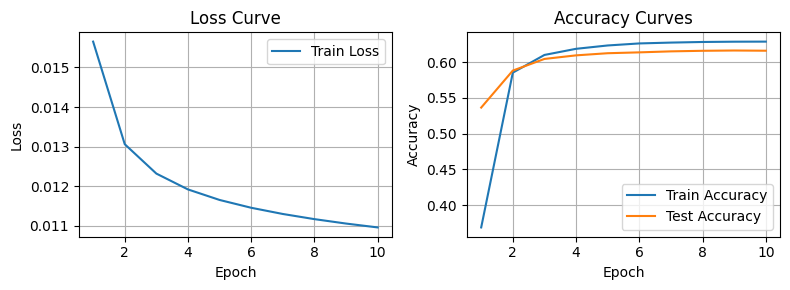

,epoch,pseudolabel_model,train_loss,train_acc,test_acc,train_detached_loss,test_detached_loss,actual_lr,epoch_time
0,1,BWD,0.015654,0.368733,0.5365,0.022543,0.022448,0.000001,9.264009
1,2,BWD,0.013060,0.585400,0.5883,0.020078,0.019968,0.000001,7.698210
2,3,BWD,0.012316,0.610183,0.6046,0.019203,0.019096,0.000001,8.009155
3,4,BWD,0.011916,0.618767,0.6096,0.018761,0.018654,0.000001,8.152311
4,5,BWD,0.011649,0.623450,0.6126,0.018500,0.018392,0.000001,8.014542
5,6,BWD,0.011452,0.626300,0.6138,0.018335,0.018226,0.000001,7.497354
6,7,BWD,0.011295,0.627483,0.6152,0.018227,0.018117,0.000001,8.016812
7,8,BWD,0.011164,0.628333,0.6160,0.018157,0.018046,0.000001,7.983755
8,9,BWD,0.011053,0.628733,0.6164,0.018112,0.018001,0.000001,7.944460
9,10,BWD,0.010955,0.628833,0.6161,0.018085,0.017974,0.000001,7.893072


In [ ]:
# #################
# Backward Proper Loss

loss_code = "cross_entropy"
#B =  weakener.Y.T
loss = ForwardBackwardProperLoss(weakener.Y.T, np.eye(weakener.c), loss_code=loss_code)
pseudolabel_model = 'BWD'

model, optimizer, metadata, results_df = run_simulation(
    Data, loss, num_epochs=num_epochs, optimizer_name=optimizer_name, 
    loss_code=loss_code, pseudolabel_model=pseudolabel_model, lr=lr)

results_df.head(num_epochs)

Initializing MLP model...
784
[]
10
Epoch 10/10: Train Loss: 0.0094, Train Acc: 0.3332, Test Acc: 0.3246, Train Detached Loss: 0.0299, Test Detached Loss: 0.0295, Learning Rate: 0.000001, Epoch Time: 7.86 seconds
                                0
pseudo_label_model            BWD
loss_name           cross_entropy
optimizer                    Adam
initial_lr               0.000001
phi                           0.8


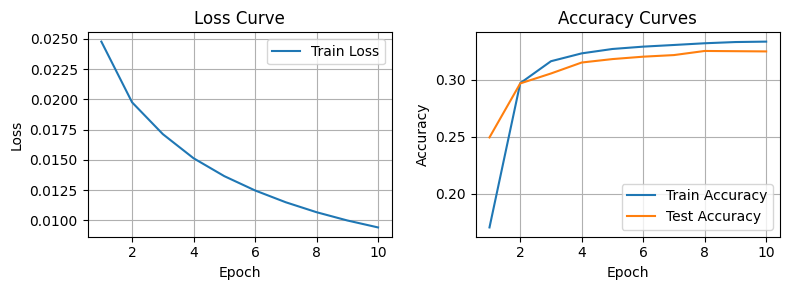

,epoch,pseudolabel_model,train_loss,train_acc,test_acc,train_detached_loss,test_detached_loss,actual_lr,epoch_time
0,1,BWD,0.024774,0.170667,0.2494,0.027685,0.027653,0.000001,7.729635
1,2,BWD,0.019751,0.296817,0.2966,0.027182,0.027105,0.000001,7.758497
2,3,BWD,0.017123,0.316033,0.3053,0.027516,0.027395,0.000001,8.069805
3,4,BWD,0.015128,0.322900,0.3149,0.027851,0.027682,0.000001,7.631294
4,5,BWD,0.013648,0.326733,0.3179,0.028260,0.028044,0.000001,8.546995
5,6,BWD,0.012466,0.328783,0.3200,0.028701,0.028436,0.000001,7.535383
6,7,BWD,0.011488,0.330233,0.3214,0.029112,0.028799,0.000001,7.570606
7,8,BWD,0.010667,0.331733,0.3250,0.029402,0.029041,0.000001,7.749032
8,9,BWD,0.009984,0.332800,0.3248,0.029682,0.029277,0.000001,7.795648
9,10,BWD,0.009408,0.333167,0.3246,0.029910,0.029469,0.000001,7.858178


In [12]:
# #################
# Backward Proper Loss

loss_code = "cross_entropy"
#B =  weakener.Y.T
loss = ForwardBackwardProperLoss(weakener.Y_opt.T, np.eye(weakener.c), loss_code=loss_code)
pseudolabel_model = 'BWD'

model, optimizer, metadata, results_df = run_simulation(
    Data, loss, num_epochs=num_epochs, optimizer_name=optimizer_name, 
    loss_code=loss_code, pseudolabel_model=pseudolabel_model, lr=lr)

results_df.head(num_epochs)

Initializing MLP model...
784
[]
10
Epoch 10/10: Train Loss: 0.0094, Train Acc: 0.3332, Test Acc: 0.3246, Train Detached Loss: 0.0299, Test Detached Loss: 0.0295, Learning Rate: 0.000001, Epoch Time: 7.90 seconds
                                0
pseudo_label_model            BWD
loss_name           cross_entropy
optimizer                    Adam
initial_lr               0.000001
phi                           0.8


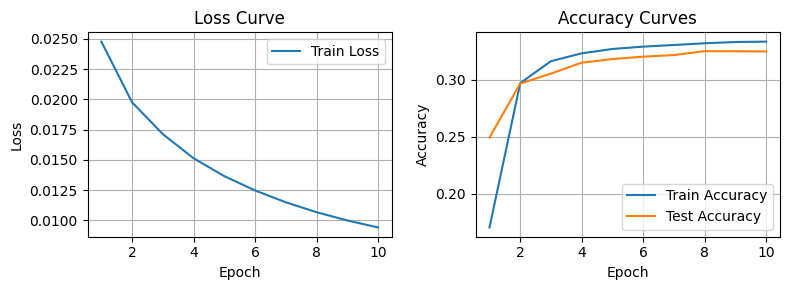

,epoch,pseudolabel_model,train_loss,train_acc,test_acc,train_detached_loss,test_detached_loss,actual_lr,epoch_time
0,1,BWD,0.024778,0.170633,0.2492,0.027685,0.027653,0.000001,8.300178
1,2,BWD,0.019757,0.296883,0.2965,0.027181,0.027104,0.000001,7.948975
2,3,BWD,0.017130,0.316067,0.3052,0.027518,0.027397,0.000001,7.950901
3,4,BWD,0.015136,0.322917,0.3147,0.027851,0.027682,0.000001,7.739909
4,5,BWD,0.013657,0.326717,0.3179,0.028259,0.028043,0.000001,7.561541
5,6,BWD,0.012476,0.328767,0.3200,0.028700,0.028435,0.000001,7.533677
6,7,BWD,0.011497,0.330217,0.3214,0.029111,0.028799,0.000001,7.835211
7,8,BWD,0.010677,0.331700,0.3248,0.029403,0.029041,0.000001,7.861598
8,9,BWD,0.009994,0.332817,0.3247,0.029681,0.029277,0.000001,7.909206
9,10,BWD,0.009419,0.333150,0.3246,0.029910,0.029469,0.000001,7.896792


In [13]:
# #################
# Backward Proper Loss

loss_code = "cross_entropy"
#B =  weakener.Y.T
loss = ForwardBackwardProperLoss(weakener.Y_opt_conv.T, np.eye(weakener.c), loss_code=loss_code)
pseudolabel_model = 'BWD'

model, optimizer, metadata, results_df = run_simulation(
    Data, loss, num_epochs=num_epochs, optimizer_name=optimizer_name, 
    loss_code=loss_code, pseudolabel_model=pseudolabel_model, lr=lr)

results_df.head(num_epochs)

Initializing MLP model...
784
[]
10
Epoch 10/10: Train Loss: 0.0307, Train Acc: 0.5753, Test Acc: 0.5687, Train Detached Loss: 0.0253, Test Detached Loss: 0.0252, Learning Rate: 0.000001, Epoch Time: 8.01 seconds
                                0
pseudo_label_model            BWD
loss_name           cross_entropy
optimizer                    Adam
initial_lr               0.000001
phi                           0.8


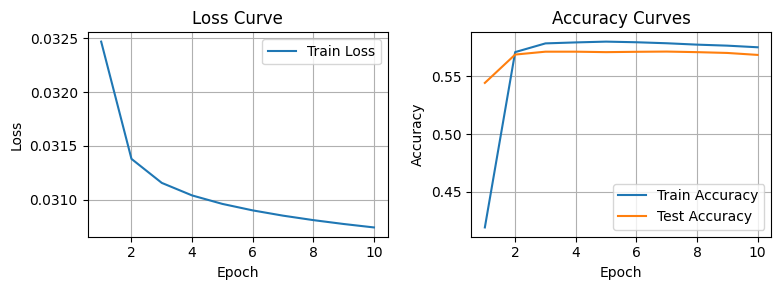

,epoch,pseudolabel_model,train_loss,train_acc,test_acc,train_detached_loss,test_detached_loss,actual_lr,epoch_time
0,1,BWD,0.032469,0.418933,0.5444,0.026088,0.026040,0.000001,8.099790
1,2,BWD,0.031379,0.571133,0.5690,0.025458,0.025417,0.000001,8.388334
2,3,BWD,0.031155,0.578700,0.5715,0.025315,0.025283,0.000001,8.187305
3,4,BWD,0.031039,0.579550,0.5715,0.025262,0.025235,0.000001,8.822479
4,5,BWD,0.030960,0.580233,0.5711,0.025240,0.025217,0.000001,8.945448
5,6,BWD,0.030900,0.579683,0.5714,0.025232,0.025212,0.000001,7.723376
6,7,BWD,0.030851,0.578817,0.5716,0.025232,0.025214,0.000001,7.700417
7,8,BWD,0.030809,0.577617,0.5711,0.025237,0.025221,0.000001,7.987550
8,9,BWD,0.030773,0.576733,0.5704,0.025244,0.025229,0.000001,7.614909
9,10,BWD,0.030741,0.575333,0.5687,0.025251,0.025238,0.000001,8.006266


In [14]:
# #################
# Backward Proper Loss

loss_code = "cross_entropy"
#B =  weakener.Y.T
loss = ForwardBackwardProperLoss(weakener.Y_conv.T, np.eye(weakener.c), loss_code=loss_code)
pseudolabel_model = 'BWD'

model, optimizer, metadata, results_df = run_simulation(
    Data, loss, num_epochs=num_epochs, optimizer_name=optimizer_name, 
    loss_code=loss_code, pseudolabel_model=pseudolabel_model, lr=lr)

results_df.head(num_epochs)